In [211]:
!pip install requests beautifulsoup4
!pip install xlrd

In [212]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

In [213]:
url = 'https://www.princetonreview.com/college-advice/sat-score-by-state'
headers = {'User-Agent': 'Mozilla/5.0'}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.content, 'html.parser')

In [214]:
rows = soup.find_all('tr')

data = []

for row in rows:
    cells = row.find_all(['th', 'td'])
    cell_text = [cell.get_text(strip=True) for cell in cells]
    if cell_text:
        data.append(cell_text)


In [215]:
rows = soup.find_all('tr')

data = []

for row in rows:
    cells = row.find_all(['th', 'td'])
    cell_text = [cell.get_text(strip=True) for cell in cells]
    if cell_text:
        data.append(cell_text)


In [216]:
#print (data[0])   Make sure first line is table column names

headers = data[0]
rows = data[1:]

SAT = pd.DataFrame(rows, columns=headers)

print(SAT.head())


        State % of students taking the SAT # of Test Takers  \
0     Alabama                           3%            1,517   
1      Alaska                          32%            2,625   
2     Arizona                          10%            8,367   
3    Arkansas                           2%              733   
4  California                          24%          120,205   

  Average Composite Score  
0                    1160  
1                    1080  
2                    1190  
3                    1190  
4                    1090  


In [217]:
print(SAT.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   State                         51 non-null     object
 1   % of students taking the SAT  51 non-null     object
 2   # of Test Takers              51 non-null     object
 3   Average Composite Score       51 non-null     object
dtypes: object(4)
memory usage: 1.7+ KB
None


In [218]:
print(SAT.describe())

          State % of students taking the SAT # of Test Takers  \
count        51                           51               51   
unique       51                           34               51   
top     Alabama                           2%            1,517   
freq          1                            7                1   

       Average Composite Score  
count                       51  
unique                      26  
top                        970  
freq                         5  


In [219]:
print(SAT.isnull())

    State  % of students taking the SAT  # of Test Takers  \
0   False                         False             False   
1   False                         False             False   
2   False                         False             False   
3   False                         False             False   
4   False                         False             False   
5   False                         False             False   
6   False                         False             False   
7   False                         False             False   
8   False                         False             False   
9   False                         False             False   
10  False                         False             False   
11  False                         False             False   
12  False                         False             False   
13  False                         False             False   
14  False                         False             False   
15  False               

In [220]:
print(SAT.duplicated().sum())

0


In [221]:
print(SAT.dtypes)

State                           object
% of students taking the SAT    object
# of Test Takers                object
Average Composite Score         object
dtype: object


In [222]:
print  (SAT['% of students taking the SAT'].value_counts())

SAT['% of students taking the SAT'] = SAT['% of students taking the SAT'].str.replace('%','', regex=False)
SAT['% of students taking the SAT'] = SAT['% of students taking the SAT'].astype(int)

print  (SAT['% of students taking the SAT'].value_counts())


% of students taking the SAT
2%      7
1%      5
100%    3
3%      3
51%     2
96%     2
4%      2
24%     1
82%     1
37%     1
43%     1
73%     1
99%     1
46%     1
23%     1
9%      1
21%     1
20%     1
61%     1
66%     1
6%      1
90%     1
32%     1
55%     1
70%     1
38%     1
76%     1
27%     1
56%     1
95%     1
10%     1
97%     1
98%     1
89%     1
Name: count, dtype: int64
% of students taking the SAT
2      7
1      5
100    3
3      3
51     2
96     2
4      2
24     1
82     1
37     1
43     1
73     1
99     1
46     1
23     1
9      1
21     1
20     1
61     1
66     1
6      1
90     1
32     1
55     1
70     1
38     1
76     1
27     1
56     1
95     1
10     1
97     1
98     1
89     1
Name: count, dtype: int64


In [223]:
#SAT['% of students taking the SAT'] = SAT['% of students taking the SAT'].astype(float)    This one has a problem
SAT['# of Test Takers'] = SAT['# of Test Takers'].astype(str)
SAT['Average Composite Score'] = SAT['Average Composite Score'].astype(int)

print(SAT.dtypes)

State                           object
% of students taking the SAT     int32
# of Test Takers                object
Average Composite Score          int32
dtype: object


In [224]:
print(SAT['State'].value_counts())
print(SAT['Average Composite Score'].value_counts())
print(SAT['# of Test Takers'].value_counts())

State
Alabama                 1
Pennsylvania            1
Nevada                  1
New Hampshire           1
New Jersey              1
New Mexico              1
New York                1
North Carolina          1
North Dakota            1
Ohio                    1
Oklahoma                1
Oregon                  1
Rhode Island            1
Montana                 1
South Carolina          1
South Dakota            1
Tennessee               1
Texas                   1
Utah                    1
Vermont                 1
Virginia                1
Washington              1
West Virginia           1
Wisconsin               1
Nebraska                1
Missouri                1
Alaska                  1
Idaho                   1
Arizona                 1
Arkansas                1
California              1
Colorado                1
Connecticut             1
Delaware                1
District of Columbia    1
Florida                 1
Georgia                 1
Hawaii                  1
Illino

In [225]:
SAT['# of Test Takers'] = SAT['# of Test Takers'].str.replace(',','', regex=False)
SAT['# of Test Takers'] = SAT['# of Test Takers'].astype(int)


print(SAT['# of Test Takers'].value_counts())

# of Test Takers
1517      1
67012     1
2028      1
12327     1
77320     1
23071     1
127993    1
23495     1
58        1
27389     1
4339      1
9847      1
11275     1
426       1
28563     1
150       1
3325      1
291694    1
771       1
2720      1
49631     1
29189     1
15683     1
1301      1
320       1
2190      1
2625      1
17603     1
8367      1
733       1
120205    1
58078     1
42020     1
10880     1
6535      1
229784    1
69136     1
4202      1
141846    1
382       1
80008     1
916       1
734       1
962       1
1117      1
5545      1
52851     1
43398     1
103396    1
2146      1
84        1
Name: count, dtype: int64


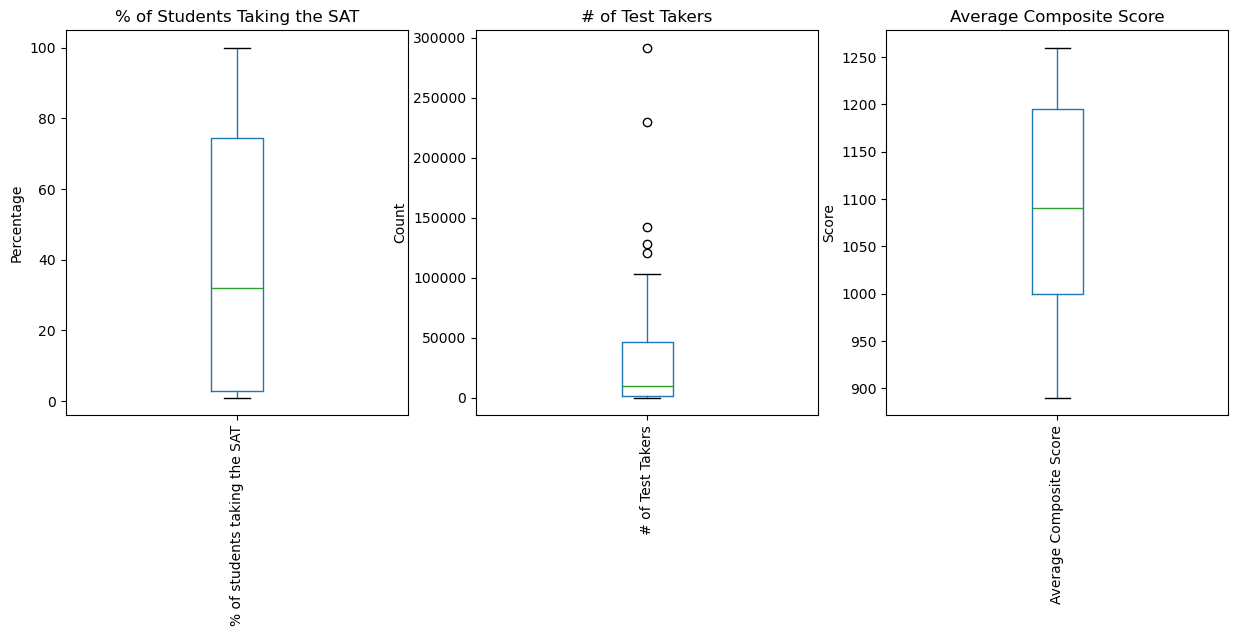

In [246]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

#'% of students taking the SAT'
SAT.boxplot(column='% of students taking the SAT', ax=ax1, grid=False)
ax1.set_title('% of Students Taking the SAT')
ax1.set_ylabel('Percentage')
ax1.tick_params(axis='x', rotation=90)

#'# of Test Takers'
SAT.boxplot(column='# of Test Takers', ax=ax2, grid=False)
ax2.set_title('# of Test Takers')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=90)

#'Average Composite Score'
SAT.boxplot(column='Average Composite Score', ax=ax3, grid=False)
ax3.set_title('Average Composite Score')
ax3.set_ylabel('Score')
ax3.tick_params(axis='x', rotation=90)

In [232]:
print(SAT.sort_values(by='# of Test Takers', ascending=False))

                   State  % of students taking the SAT  # of Test Takers  \
43                 Texas                            73            291694   
9                Florida                            95            229784   
13              Illinois                            96            141846   
32              New York                            61            127993   
4             California                            24            120205   
22              Michigan                            96            103396   
14               Indiana                           100             80008   
30            New Jersey                            66             77320   
10               Georgia                            56             69136   
38          Pennsylvania                            46             67012   
5               Colorado                            90             58078   
20              Maryland                            70             52851   
46          

In [233]:
###############################################

In [234]:
url = 'https://www.act.org/content/act/en/products-and-services/the-act/scores/average-act-test-scores-by-state.html'
headers = {'User-Agent': 'Mozilla/5.0'}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.content, 'html.parser')

In [235]:
rows = soup.find_all('tr')

data = []

for row in rows:
    cells = row.find_all(['th', 'td'])
    cell_text = [cell.get_text(strip=True) for cell in cells]
    if cell_text:
        data.append(cell_text)

In [236]:
#print (data[0])   Make sure first line is table column names

headers = data[0]
rows = data[1:]

ACT = pd.DataFrame(rows, columns=headers)

print(ACT.head(2))


     State Estimated % of Grads Tested Average Composite Score  \
0  Alabama                         100                    18.0   
1  Arizona                         100                    17.7   

  % Meeting English Benchmark (18) % Meeting Math Benchmark (22)  \
0                               43                            18   
1                               41                            22   

  % Meeting Reading Benchmark (22) % Meeting Science Benchmark (23)  
0                               30                               21  
1                               28                               19  


In [237]:
print(ACT.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   State                             52 non-null     object
 1   Estimated % of Grads Tested       52 non-null     object
 2   Average Composite Score           52 non-null     object
 3   % Meeting English Benchmark (18)  52 non-null     object
 4   % Meeting Math Benchmark (22)     52 non-null     object
 5   % Meeting Reading Benchmark (22)  52 non-null     object
 6   % Meeting Science Benchmark (23)  52 non-null     object
dtypes: object(7)
memory usage: 3.0+ KB
None


In [238]:
print(ACT.describe())

          State Estimated % of Grads Tested Average Composite Score  \
count        52                          52                      52   
unique       52                          30                      36   
top     Alabama                         100                    19.4   
freq          1                           9                       3   

       % Meeting English Benchmark (18) % Meeting Math Benchmark (22)  \
count                                52                            52   
unique                               31                            35   
top                                  85                            30   
freq                                  5                             4   

       % Meeting Reading Benchmark (22) % Meeting Science Benchmark (23)  
count                                52                               52  
unique                               34                               33  
top                                  36              

In [239]:
print(ACT.isnull())

    State  Estimated % of Grads Tested  Average Composite Score  \
0   False                        False                    False   
1   False                        False                    False   
2   False                        False                    False   
3   False                        False                    False   
4   False                        False                    False   
5   False                        False                    False   
6   False                        False                    False   
7   False                        False                    False   
8   False                        False                    False   
9   False                        False                    False   
10  False                        False                    False   
11  False                        False                    False   
12  False                        False                    False   
13  False                        False                    Fals

In [240]:
print(ACT.duplicated().sum())

0


In [241]:
print(ACT.dtypes)

State                               object
Estimated % of Grads Tested         object
Average Composite Score             object
% Meeting English Benchmark (18)    object
% Meeting Math Benchmark (22)       object
% Meeting Reading Benchmark (22)    object
% Meeting Science Benchmark (23)    object
dtype: object


In [242]:
ACT['Estimated % of Grads Tested'] = ACT['Estimated % of Grads Tested'].astype(float)
ACT['Average Composite Score'] = ACT['Average Composite Score'].astype(float)
ACT['% Meeting English Benchmark (18)'] = ACT['% Meeting English Benchmark (18)'].astype(float)
ACT['% Meeting Math Benchmark (22)'] = ACT['% Meeting Math Benchmark (22)'].astype(float)
ACT['% Meeting Reading Benchmark (22)'] = ACT['% Meeting Reading Benchmark (22)'].astype(float)
ACT['% Meeting Science Benchmark (23)'] = ACT['% Meeting Science Benchmark (23)'].astype(float)

print(ACT.dtypes)

State                                object
Estimated % of Grads Tested         float64
Average Composite Score             float64
% Meeting English Benchmark (18)    float64
% Meeting Math Benchmark (22)       float64
% Meeting Reading Benchmark (22)    float64
% Meeting Science Benchmark (23)    float64
dtype: object


In [243]:
print(ACT['State'].value_counts())

State
Alabama                 1
Arizona                 1
District of Columbia    1
Illinois                1
Alaska                  1
Oregon                  1
New Mexico              1
Idaho                   1
New Jersey              1
Colorado                1
Connecticut             1
New York                1
Virginia                1
Indiana                 1
Massachusetts           1
Maryland                1
Michigan                1
Vermont                 1
Pennsylvania            1
Washington              1
Delaware                1
New Hampshire           1
Rhode Island            1
California              1
Maine                   1
West Virginia           1
Texas                   1
Georgia                 1
Wisconsin               1
Kentucky                1
Louisiana               1
Mississippi             1
Nevada                  1
Oklahoma                1
Tennessee               1
Wyoming                 1
Montana                 1
Arkansas                1
Nebras

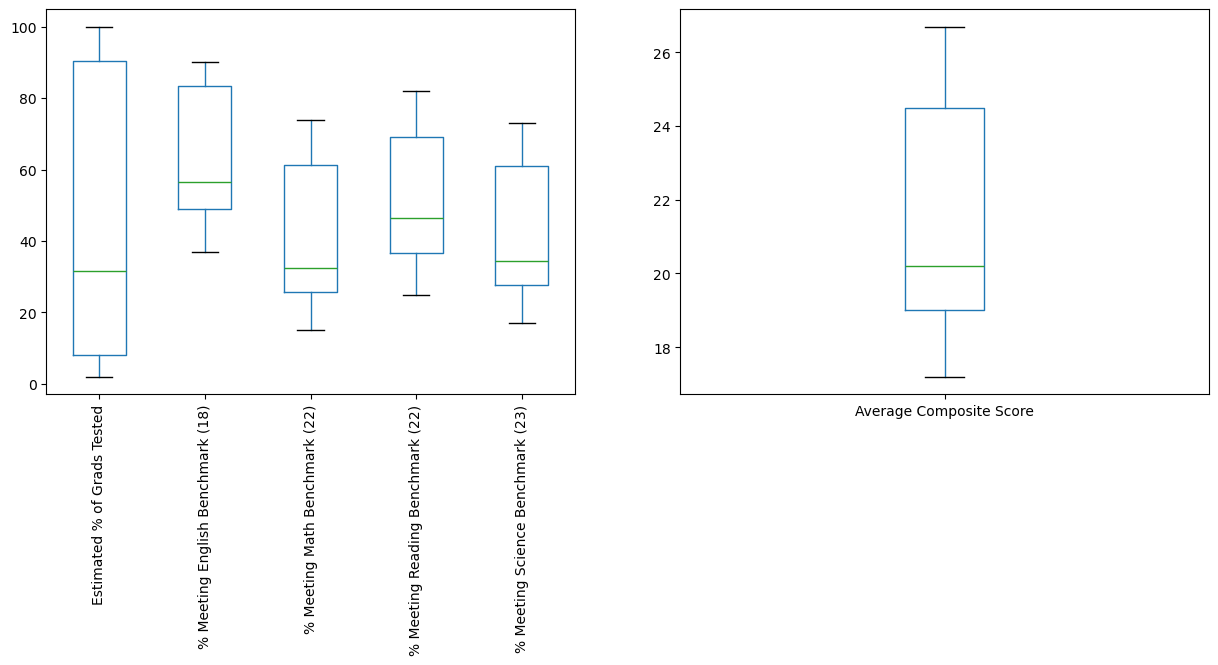

In [248]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

plt.xticks(rotation = 75)

ACT.boxplot(column=['Estimated % of Grads Tested', 
                    '% Meeting English Benchmark (18)',
                    '% Meeting Math Benchmark (22)',
                    '% Meeting Reading Benchmark (22)',
                    '% Meeting Science Benchmark (23)'],
            rot=90,
            ax=ax1,
           grid=False)

ACT.boxplot(column='Average Composite Score', ax=ax2, grid=False)

plt.show()

In [268]:
###############################################

In [275]:
# Reading directly from the URL looking for <table> tags
url = 'https://nces.ed.gov/programs/digest/d23/tables/dt23_219.46.asp'

ACGR = tables[2]
ACGR.head(10)

,0,1,2,3,4,5,6,7,8,9,...,37,38,39,40,41,42,43,44,45,46
0,State or jurisdiction,"Total, ACGR for all students","Total, ACGR for all students","Total, ACGR for all students","Total, ACGR for all students","Total, ACGR for all students","Total, ACGR for all students","Total, ACGR for all students","Total, ACGR for all students","Total, ACGR for all students",...,ACGR for students with selected characteristic...,ACGR for students with selected characteristic...,ACGR for students with selected characteristic...,ACGR for students with selected characteristic...,ACGR for students with selected characteristic...,ACGR for students with selected characteristic...,ACGR for students with selected characteristic...,ACGR for students with selected characteristic...,ACGR for students with selected characteristic...,ACGR for students with selected characteristic...
1,State or jurisdiction,2011- 12,2011- 12,2012- 13,2012- 13,2013- 14,2014- 15,2015- 16,2016- 17,2017- 18,...,Race/ethnicity,Race/ethnicity,Race/ethnicity,Race/ethnicity,Students with disabil- ities2,English learner3,English learner3,Economi- cally disadvan- taged4,Homeless enrolled,Foster care
2,State or jurisdiction,2011- 12,2011- 12,2012- 13,2012- 13,2013- 14,2014- 15,2015- 16,2016- 17,2017- 18,...,Black,Hispanic,White,Two or more races,Students with disabil- ities2,English learner3,English learner3,Economi- cally disadvan- taged4,Homeless enrolled,Foster care
3,State or jurisdiction,2011- 12,2011- 12,2012- 13,2012- 13,2013- 14,2014- 15,2015- 16,2016- 17,2017- 18,...,Black,Hispanic,White,Two or more races,Students with disabil- ities2,English learner3,English learner3,Economi- cally disadvan- taged4,Homeless enrolled,Foster care
4,1,2,2,3,3,4,5,6,7,8,...,30,31,32,33,34,35,35,36,37,38
5,United States,80,6,81,7,82,83,84,85,85,...,81,83,90,---,71,72,NaN,81,68,---
6,Alabama12,75,NaN,80,NaN,86,89,87,89,90,...,85,84,90,90,74,68,NaN,83,76,64
7,Alaska,70,NaN,72,NaN,71,76,76,78,79,...,74,77,84,75,61,65,NaN,70,59,53
8,Arizona,76,NaN,75,NaN,76,77,80,78,79,...,72,73,83,78,67,60,NaN,73,48,39
9,Arkansas,84,NaN,85,NaN,87,85,87,88,89,...,85,87,90,86,83,82,NaN,85,78,64


In [276]:
ACGR = ACGR.iloc[3:]   #shaving off unneeded rows
ACGR.head(10)

,0,1,2,3,4,5,6,7,8,9,...,37,38,39,40,41,42,43,44,45,46
3,State or jurisdiction,2011- 12,2011- 12,2012- 13,2012- 13,2013- 14,2014- 15,2015- 16,2016- 17,2017- 18,...,Black,Hispanic,White,Two or more races,Students with disabil- ities2,English learner3,English learner3,Economi- cally disadvan- taged4,Homeless enrolled,Foster care
4,1,2,2,3,3,4,5,6,7,8,...,30,31,32,33,34,35,35,36,37,38
5,United States,80,6,81,7,82,83,84,85,85,...,81,83,90,---,71,72,NaN,81,68,---
6,Alabama12,75,NaN,80,NaN,86,89,87,89,90,...,85,84,90,90,74,68,NaN,83,76,64
7,Alaska,70,NaN,72,NaN,71,76,76,78,79,...,74,77,84,75,61,65,NaN,70,59,53
8,Arizona,76,NaN,75,NaN,76,77,80,78,79,...,72,73,83,78,67,60,NaN,73,48,39
9,Arkansas,84,NaN,85,NaN,87,85,87,88,89,...,85,87,90,86,83,82,NaN,85,78,64
10,California,79,NaN,80,NaN,81,82,83,83,83,...,79,85,91,87,74,72,NaN,85,73,61
11,Colorado,75,NaN,77,NaN,77,77,79,79,81,...,77,75,87,81,68,69,NaN,72,55,30
12,Connecticut,85,NaN,86,NaN,87,87,87,88,88,...,82,81,94,89,70,70,NaN,82,67,57


In [277]:
ACGR = ACGR.iloc[:, :17]  #shaving off extra columns (these deal with minority status, language, homelessness, etc.)
ACGR.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
3,State or jurisdiction,2011- 12,2011- 12,2012- 13,2012- 13,2013- 14,2014- 15,2015- 16,2016- 17,2017- 18,2018- 19,2019- 20,2019- 20,2020- 21,2020- 21,2021- 22,2021- 22
4,1,2,2,3,3,4,5,6,7,8,9,NaN,10,NaN,11,12,12
5,United States,80,6,81,7,82,83,84,85,85,86,87,8,86,9,87,10
6,Alabama12,75,NaN,80,NaN,86,89,87,89,90,92,91,NaN,91,NaN,88,NaN
7,Alaska,70,NaN,72,NaN,71,76,76,78,79,80,79,NaN,78,NaN,78,NaN
8,Arizona,76,NaN,75,NaN,76,77,80,78,79,78,77,NaN,76,NaN,77,NaN
9,Arkansas,84,NaN,85,NaN,87,85,87,88,89,88,89,NaN,88,NaN,88,NaN
10,California,79,NaN,80,NaN,81,82,83,83,83,85,84,NaN,84,NaN,87,NaN
11,Colorado,75,NaN,77,NaN,77,77,79,79,81,81,82,NaN,82,NaN,82,NaN
12,Connecticut,85,NaN,86,NaN,87,87,87,88,88,89,88,NaN,90,NaN,89,NaN


In [278]:
ACGR.columns = ACGR.iloc[0]    # Setting first row as column names
ACGR = ACGR[1:]               
ACGR = ACGR.reset_index(drop=True)

In [280]:
ACGR = ACGR.set_index(ACGR.columns[0])

In [281]:
print(ACGR.head())

3                     2011- 12 2011- 12 2012- 13 2012- 13 2013- 14 2014- 15  \
State or jurisdiction                                                         
1                            2        2        3        3        4        5   
United States               80        6       81        7       82       83   
Alabama12                   75      NaN       80      NaN       86       89   
Alaska                      70      NaN       72      NaN       71       76   
Arizona                     76      NaN       75      NaN       76       77   

3                     2015- 16 2016- 17 2017- 18 2018- 19 2019- 20 2019- 20  \
State or jurisdiction                                                         
1                            6        7        8        9      NaN       10   
United States               84       85       85       86       87        8   
Alabama12                   87       89       90       92       91      NaN   
Alaska                      76       78       79   

In [282]:
print(ACGR.info())

<class 'pandas.core.frame.DataFrame'>
Index: 73 entries, 1 to SOURCE: U.S. Department of Education, National Center for  Education Statistics, EDFacts file 150, Data Group 695, and EDFacts file 151, Data  Group 696, 2011-12 through 2021-22. (This table was prepared January 2024.)
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   2011- 12  72 non-null     object
 1   2011- 12  19 non-null     object
 2   2012- 13  72 non-null     object
 3   2012- 13  19 non-null     object
 4   2013- 14  72 non-null     object
 5   2014- 15  72 non-null     object
 6   2015- 16  72 non-null     object
 7   2016- 17  72 non-null     object
 8   2017- 18  72 non-null     object
 9   2018- 19  72 non-null     object
 10  2019- 20  71 non-null     object
 11  2019- 20  19 non-null     object
 12  2020- 21  71 non-null     object
 13  2020- 21  19 non-null     object
 14  2021- 22  72 non-null     object
 15  2021- 22  19 non-null     object
dt

In [285]:
print (ACGR.describe())

3      2011- 12 2011- 12 2012- 13 2012- 13 2013- 14 2014- 15 2015- 16  \
count        72       19       72       19       72       72       72   
unique       39       19       40       19       42       38       37   
top          75        2       86        3       87       88       88   
freq          5        1        7        1        7        7        6   

3      2016- 17 2017- 18 2018- 19 2019- 20 2019- 20 2020- 21 2020- 21  \
count        72       72       72       71       19       71       19   
unique       36       33       36       35       19       35       19   
top          87       87       87       84       10       90       11   
freq          8        7        9        7        1        8        1   

3      2021- 22 2021- 22  
count        72       19  
unique       36       19  
top          90       12  
freq          7        1  


In [286]:
print (ACGR.isnull().sum())

3
2011- 12     1
2011- 12    54
2012- 13     1
2012- 13    54
2013- 14     1
2014- 15     1
2015- 16     1
2016- 17     1
2017- 18     1
2018- 19     1
2019- 20     2
2019- 20    54
2020- 21     2
2020- 21    54
2021- 22     1
2021- 22    54
dtype: int64
